### **ibrahim johar farooqi**
### 23K-0074
### BAI-6A

### DLP Assignment 03 - DCGAN on MNIST
implementing a deep convolutional generative adversarial network to generate handwritten digits.

**ref:** Radford et al., *Unsupervised Representation Learning with Deep Convolutional Generative Adversarial Networks* (arXiv: 1511.06434)

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import os
from tqdm import tqdm

hyperparameters follow the recommendations from the DCGAN paper.

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"using device: {device}")
#hyperparameters (from DCGAN paper)
LEARNING_RATE = 2e-4
BATCH_SIZE = 128
IMAGE_SIZE = 64
CHANNELS_IMG = 1        #MNIST is grayscale
NOISE_DIM = 100         #size of the latent noise vector z
NUM_EPOCHS = 25
FEATURES_DISC = 64
FEATURES_GEN = 64

using device: cuda


#### dataset
MNIST images are 28×28; resize them to 64×64 to match the DCGAN architecture, & normalize to [-1, 1] (matching the generator's Tanh output).

In [3]:
transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))    #maps [0,1] -> [-1,1]
])

dataset = torchvision.datasets.MNIST(root="./data", train=True, transform=transform, download=True)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

print(f"dataset size: {len(dataset)} images")

100%|██████████| 9.91M/9.91M [00:08<00:00, 1.21MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 135kB/s]
100%|██████████| 1.65M/1.65M [00:02<00:00, 771kB/s] 
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.34MB/s]

dataset size: 60000 images


### **model architecture**
#### **discriminator**
takes a 64×64 image & outputs a single probability (real or fake).
- uses strided Conv2d to downsample (no pooling layers, as per the paper)
- leakyReLU(0.2) activations throughout
- BatchNorm on all layers except the first input layer
- Sigmoid on the final output

In [4]:
class Discriminator(nn.Module):
    def __init__(self, channels_img, features_d):
        super(Discriminator, self).__init__()
        
        self.disc = nn.Sequential(
            #input: N x channels_img x 64 x 64
            #no BatchNorm on first layer (per DCGAN paper)
            nn.Conv2d(channels_img, features_d, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            #-> 32x32
            self._block(features_d, features_d * 2, 4, 2, 1),      #-> 16x16
            self._block(features_d * 2, features_d * 4, 4, 2, 1),  #-> 8x8
            self._block(features_d * 4, features_d * 8, 4, 2, 1),  #-> 4x4
            
            #final conv collapses spatial dims to 1x1
            nn.Conv2d(features_d * 8, 1, kernel_size=4, stride=2, padding=0),
            nn.Sigmoid(),
        )

    def _block(self, in_channels, out_channels, kernel_size, stride, padding):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.LeakyReLU(0.2),
        )

    def forward(self, x):
        return self.disc(x)

#### **generator**
takes a noise vector z (100-dim) & upsamples it into a 64×64 image.
- uses ConvTranspose2d (fractional-strided convolutions) to upsample
- ReLU activations, BatchNorm on all layers except the output
- Tanh on the final output (matches the [-1,1] normalization of real images)

In [5]:
class Generator(nn.Module):
    def __init__(self, channels_noise, channels_img, features_g):
        super(Generator, self).__init__()

        self.net = nn.Sequential(
            #input: N x channels_noise x 1 x 1
            self._block(channels_noise, features_g * 16, 4, 1, 0),  #-> 4x4
            self._block(features_g * 16, features_g * 8, 4, 2, 1),  #-> 8x8
            self._block(features_g * 8, features_g * 4, 4, 2, 1),   #-> 16x16
            self._block(features_g * 4, features_g * 2, 4, 2, 1),   #-> 32x32
            #output layer: no BatchNorm, Tanh activation
            nn.ConvTranspose2d(features_g * 2, channels_img, kernel_size=4, stride=2, padding=1),
            nn.Tanh(),  #output: N x channels_img x 64 x 64
        )

    def _block(self, in_channels, out_channels, kernel_size, stride, padding):
        return nn.Sequential(
            nn.ConvTranspose2d(in_channels, out_channels, kernel_size, stride, padding, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
        )

    def forward(self, x):
        return self.net(x)

**weight initialization**

DCGAN paper recommends initializing all Conv & BatchNorm weights from a normal distribution w/ mean=0 and std=0.02.

In [6]:
def initialize_weights(model):
    for m in model.modules():
        if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
            nn.init.normal_(m.weight.data, 0.0, 0.02)
        if isinstance(m, nn.BatchNorm2d):
            nn.init.normal_(m.weight.data, 1.0, 0.02)
            nn.init.constant_(m.bias.data, 0)

**initialising models, optimizers, & loss**

In [8]:
gen = Generator(NOISE_DIM, CHANNELS_IMG, FEATURES_GEN).to(device)
disc = Discriminator(CHANNELS_IMG, FEATURES_DISC).to(device)

initialize_weights(gen)
initialize_weights(disc)

#binary cross entropy loss
criterion = nn.BCELoss()

#adam optimizer with beta1=0.5 as recommended in DCGAN paper
opt_gen = optim.Adam(gen.parameters(), lr=LEARNING_RATE, betas=(0.5, 0.999))
opt_disc = optim.Adam(disc.parameters(), lr=LEARNING_RATE, betas=(0.5, 0.999))

#fixed noise to track generator progress across epochs
fixed_noise = torch.randn(16, NOISE_DIM, 1, 1).to(device)

os.makedirs("samples", exist_ok=True)
print("models initialized.")

models initialized.


**training loop**

each iteration:
1. **train discriminator**:   $max{\space}(log(D(real)) + log(1 - D(G(z))))$
2. **train generator**:   $max{\space}(log(D(G(z))))$ - which is essentially fooling the discriminator

In [9]:
gen.train()
disc.train()

#tracking losses for plotting later
d_losses = []
g_losses = []

for epoch in range(NUM_EPOCHS):
    epoch_d_loss = 0
    epoch_g_loss = 0
    loop = tqdm(dataloader, desc=f"Epoch [{epoch+1}/{NUM_EPOCHS}]", leave=True)

    for batch_idx, (real, _) in enumerate(loop):
        real = real.to(device)
        batch_size = real.size(0)

        #train discriminator
        noise = torch.randn(batch_size, NOISE_DIM, 1, 1).to(device)
        fake = gen(noise)

        disc_real = disc(real).reshape(-1)
        disc_fake = disc(fake.detach()).reshape(-1)     #detach here so we dont backprop into gen

        loss_disc_real = criterion(disc_real, torch.ones_like(disc_real))
        loss_disc_fake = criterion(disc_fake, torch.zeros_like(disc_fake))
        loss_disc = (loss_disc_real + loss_disc_fake) / 2

        disc.zero_grad()
        loss_disc.backward()
        opt_disc.step()

        #train generator
        output = disc(fake).reshape(-1)
        loss_gen = criterion(output, torch.ones_like(output))  #gen wants disc to output 1

        gen.zero_grad()
        loss_gen.backward()
        opt_gen.step()

        epoch_d_loss += loss_disc.item()
        epoch_g_loss += loss_gen.item()

        loop.set_postfix(loss_D=f"{loss_disc.item():.4f}", loss_G=f"{loss_gen.item():.4f}")

    #save avg loss per epoch
    d_losses.append(epoch_d_loss / len(dataloader))
    g_losses.append(epoch_g_loss / len(dataloader))

    #save grid of 16 generated images every epoch
    gen.eval()
    with torch.no_grad():
        fake_samples = gen(fixed_noise)
        torchvision.utils.save_image(fake_samples, f"samples/epoch_{epoch+1:02d}.png", nrow=4, normalize=True)
    gen.train()

print("\ntraining complete!")

Epoch [25/25]: 100%|██████████| 469/469 [03:29<00:00,  2.24it/s, loss_D=0.0036, loss_G=8.0476] 


training complete!


#### **training loss plot**

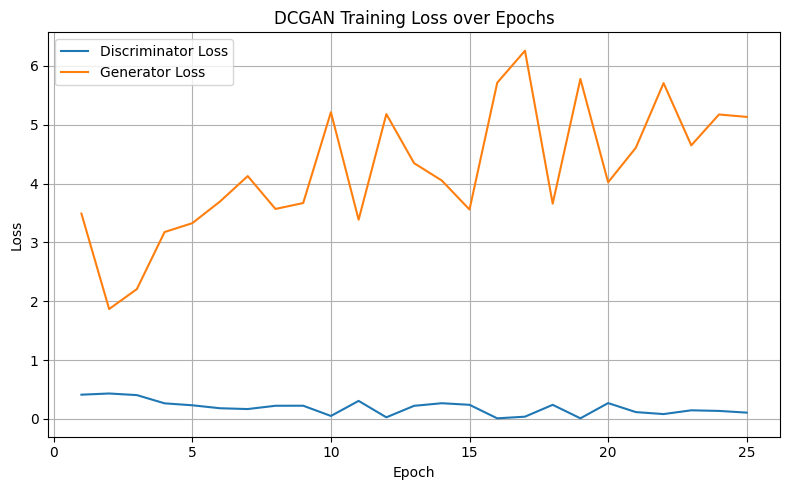

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, NUM_EPOCHS + 1), d_losses, label="Discriminator Loss")
plt.plot(range(1, NUM_EPOCHS + 1), g_losses, label="Generator Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DCGAN Training Loss over Epochs")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("samples/training_loss.png", dpi=150)
plt.show()

**visualizing gen samples**

comparing outputs at diff training stages.

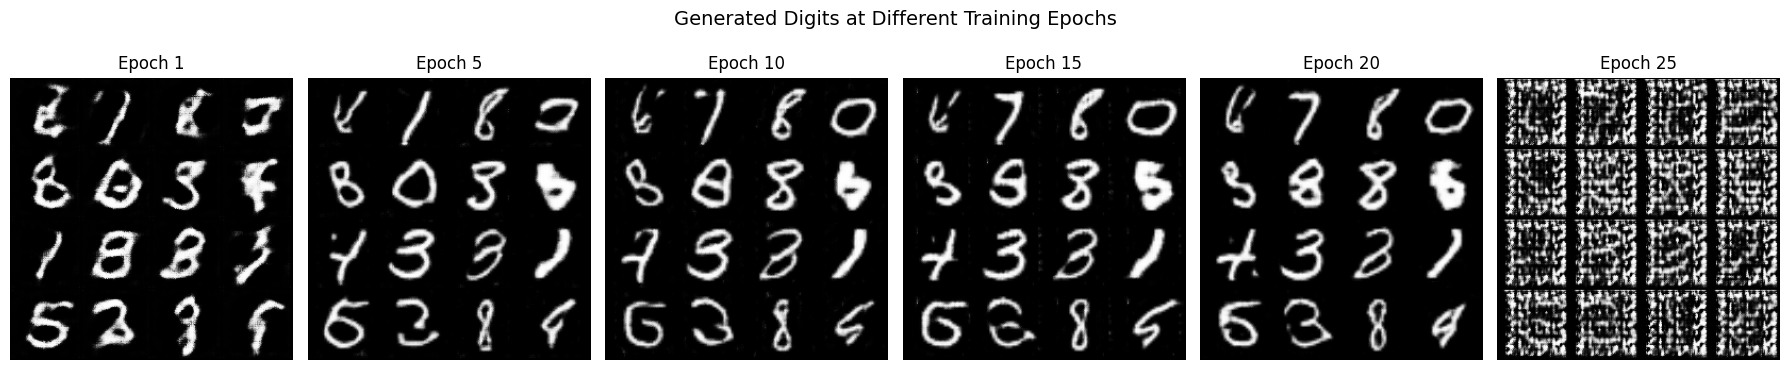

In [11]:
from PIL import Image

epochs_to_show = [1, 5, 10, 15, 20, 25]
fig, axes = plt.subplots(1, len(epochs_to_show), figsize=(18, 4))

for ax, ep in zip(axes, epochs_to_show):
    path = f"samples/epoch_{ep:02d}.png"
    if os.path.exists(path):
        img = Image.open(path)
        ax.imshow(img, cmap="gray")
        ax.set_title(f"Epoch {ep}")
    else:
        ax.set_title(f"Epoch {ep}\n(not saved)")
    ax.axis("off")

plt.suptitle("Generated Digits at Different Training Epochs", fontsize=14)
plt.tight_layout()
plt.savefig("samples/comparison.png", dpi=150)
plt.show()

#### **observations**
training produced clear, recognizable digits from epoch 1 onwards, with quality improving steadily up to epoch 24. however, at epoch 25 the generator collapsed and began producing noise. this is apparently a known GAN failure mode where the discriminator loss dropped extremely low (like around ~0.003) while the generator loss spiked to around ~7.6, meaning the discriminator became too strong and the generator could no longer receive useful gradients to learn from. best results were observed at epoch 24, which is used as the final output.

**final generated samples (atleast 10 digits)**

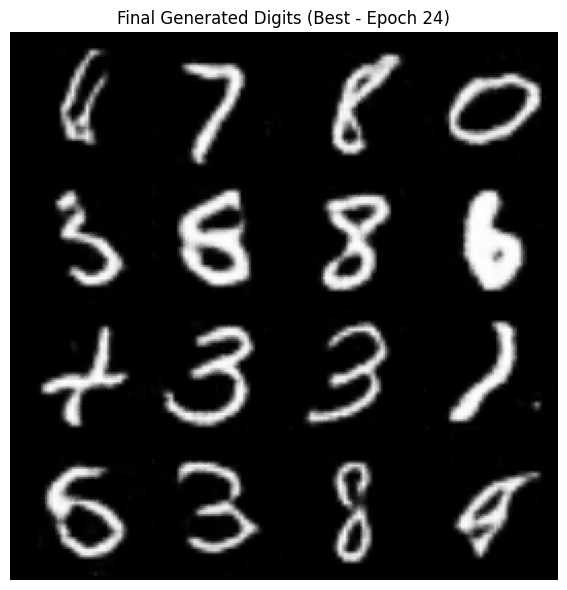

all outputs saved to the 'samples/' folder.


In [15]:
from PIL import Image

img = Image.open("samples/epoch_24.png")

plt.figure(figsize=(6, 6))
plt.imshow(img, cmap="gray")
plt.title("Final Generated Digits (Best - Epoch 24)")
plt.axis("off")
plt.tight_layout()
plt.savefig("samples/final_generated.png", dpi=350)
plt.show()

print("all outputs saved to the 'samples/' folder.")